# VGG16 NTW Dataset — Image-Level Evaluation (Corrected)

This notebook runs two VGG16 experiments on the combined NEUROCON–Tao Wu (NTW) MRI dataset:

1. Frozen VGG16 backbone
2. Fine-tuned VGG16 backbone

It saves model summaries, parameter counts, histories, accuracy/loss/AUC graphs, all metrics, classification reports, confusion matrices, ROC curves, NPZ files, prediction CSV files, and Grad-CAM images.

Change only the three paths in the configuration cell.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:


import os, json, random, shutil, zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# =========================
# USER PATHS
# =========================
ZIP_PATH = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_dataset_here/Parkinson_dataset_2.zip"
UNZIP_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_dataset_unzip_here"
SAVE_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

FROZEN_EPOCHS = 35
WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
FINE_TUNE_LAST_LAYERS = 8

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Results will be saved to:", SAVE_DIR)

Results will be saved to: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here


In [ ]:
# =========================
# UNZIP AND FIND DATASET ROOT
# =========================
if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if Path(UNZIP_DIR).exists():
    shutil.rmtree(UNZIP_DIR)
Path(UNZIP_DIR).mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(UNZIP_DIR)

def find_dataset_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "healthy_control").is_dir() and (candidate / "parkinson").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a folder containing both healthy_control and parkinson."
    )

DATASET_ROOT = find_dataset_root(UNZIP_DIR)
print("Dataset root:", DATASET_ROOT)

Dataset root: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_dataset_unzip_here/sagittal_images


In [ ]:
# =========================
# BUILD METADATA
# =========================
valid_ext = {".png", ".jpg", ".jpeg", ".bmp"}
class_map = {"healthy_control": 0, "parkinson": 1}

records = []
for class_name, label in class_map.items():
    for image_path in (DATASET_ROOT / class_name).rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in valid_ext:
            records.append({
                "filepath": str(image_path),
                "label": label,
                "class_name": class_name,
                "patient_id": image_path.parent.name,
                "source_dataset": image_path.parent.parent.name,
            })

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)

print("Total images:", len(df))
print(df["class_name"].value_counts())
print("\nParticipants by class:")
print(df.groupby("class_name")["patient_id"].nunique())
print("\nImages by source:")
print(df["source_dataset"].value_counts())
print("\nTotal participants:", df["patient_id"].nunique())
print("\nImages per participant:")
display(df.groupby("patient_id").size().describe().to_frame("count"))

if len(df) != 3320:
    print(f"Warning: expected 3320 images, found {len(df)}")
if df["patient_id"].nunique() != 83:
    print(f"Warning: expected 83 participants, found {df['patient_id'].nunique()}")

df.to_csv(Path(SAVE_DIR) / "NTW_complete_metadata.csv", index=False)

Total images: 3320
class_name
parkinson          1880
healthy_control    1440
Name: count, dtype: int64

Participants by class:
class_name
healthy_control    36
parkinson          47
Name: patient_id, dtype: int64

Images by source:
source_dataset
NEUROCON    1720
Tao_Wu      1600
Name: count, dtype: int64

Total participants: 83

Images per participant:


,count
count,83.0
mean,40.0
std,0.0
min,40.0
25%,40.0
50%,40.0
75%,40.0
max,40.0


In [ ]:
# =========================
# IMAGE-LEVEL 70/15/15 SPLIT
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

for name, frame in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name}: {len(frame)} images")
    print(frame["class_name"].value_counts())

train_df.to_csv(Path(SAVE_DIR) / "image_train_split.csv", index=False)
val_df.to_csv(Path(SAVE_DIR) / "image_validation_split.csv", index=False)
test_df.to_csv(Path(SAVE_DIR) / "image_test_split.csv", index=False)


Train: 2324 images
class_name
parkinson          1316
healthy_control    1008
Name: count, dtype: int64

Validation: 498 images
class_name
parkinson          282
healthy_control    216
Name: count, dtype: int64

Test: 498 images
class_name
parkinson          282
healthy_control    216
Name: count, dtype: int64


In [ ]:
# =========================
# TF.DATA PIPELINE
# =========================
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential([
    layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
    layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
    layers.RandomTranslation(0.05, 0.05, fill_mode="nearest", seed=SEED),
], name="augmentation")

def load_image(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image, training=True)

    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["filepath"].astype(str).values,
         frame["label"].astype("float32").values)
    )
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y: load_image(p, y, training),
        num_parallel_calls=AUTOTUNE
    )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [ ]:
# =========================
# MODEL AND UTILITY FUNCTIONS
# =========================
def build_vgg16_model(model_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="mri_input")

    backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(256, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.50, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    return keras.Model(inputs, outputs, name=model_name), backbone

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def save_summary(model, path):
    lines = []
    model.summary(print_fn=lines.append)
    Path(path).write_text("\n".join(lines), encoding="utf-8")
    print("\n".join(lines))

def get_parameter_counts(model):
    trainable = sum(int(tf.keras.backend.count_params(w)) for w in model.trainable_weights)
    non_trainable = sum(int(tf.keras.backend.count_params(w)) for w in model.non_trainable_weights)
    total = trainable + non_trainable
    return pd.DataFrame([{
        "model": model.name,
        "total_parameters": total,
        "trainable_parameters": trainable,
        "non_trainable_parameters": non_trainable,
    }])

def combine_histories(*histories):
    merged = {}
    for h in histories:
        for key, values in h.history.items():
            merged.setdefault(key, [])
            merged[key].extend([float(v) for v in values])
    return merged

def save_history(history, folder, prefix):
    pd.DataFrame(history).to_csv(Path(folder) / f"{prefix}_history.csv", index=False)
    with open(Path(folder) / f"{prefix}_history.json", "w") as f:
        json.dump(history, f, indent=2)

def plot_history(history, folder, title_prefix, prefix, fine_tune_start=None):
    epochs = np.arange(1, len(history["loss"]) + 1)

    for metric, ylabel, suffix in [
        ("accuracy", "Accuracy", "accuracy"),
        ("loss", "Binary Cross-Entropy Loss", "loss"),
        ("auc", "ROC-AUC", "auc"),
    ]:
        plt.figure(figsize=(9, 6))
        plt.plot(epochs, history[metric], linewidth=2, label=f"Training {ylabel}")
        plt.plot(epochs, history[f"val_{metric}"], linewidth=2, label=f"Validation {ylabel}")

        if fine_tune_start is not None:
            plt.axvline(
                fine_tune_start,
                linestyle="--",
                linewidth=1.5,
                label="Fine-Tuning Start",
            )

        plt.title(f"{title_prefix} {ylabel}", fontsize=15, fontweight="bold")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        if metric in ("accuracy", "auc"):
            plt.ylim(0, 1.02)
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(Path(folder) / f"{prefix}_{suffix}.png", dpi=300, bbox_inches="tight")
        plt.show()

In [ ]:
# =========================
# EVALUATION FUNCTION
# =========================
def evaluate_model(model, dataset, frame, folder, display_name, prefix):
    folder = Path(folder)
    probs = model.predict(dataset, verbose=1).ravel()
    y_true = frame["label"].to_numpy(dtype=int)
    y_pred = (probs >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Model": display_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probs),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Test_Images": len(y_true),
    }

    metrics_df = pd.DataFrame([metrics])
    display(metrics_df)
    metrics_df.to_csv(folder / f"{prefix}_metrics.csv", index=False)

    report = classification_report(
        y_true, y_pred,
        target_names=["Healthy Control", "Parkinson"],
        digits=4, zero_division=0
    )
    print(report)
    (folder / f"{prefix}_classification_report.txt").write_text(report)

    pred_df = frame[[
        "filepath", "patient_id", "source_dataset", "class_name", "label"
    ]].copy()
    pred_df["probability_parkinson"] = probs
    pred_df["predicted_label"] = y_pred
    pred_df.to_csv(folder / f"{prefix}_test_predictions.csv", index=False)

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{display_name}\nConfusion Matrix", fontweight="bold")
    plt.xticks([0, 1], ["Healthy Control", "Parkinson"])
    plt.yticks([0, 1], ["Healthy Control", "Parkinson"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    threshold = cm.max() / 2
    for i in range(2):
        for j in range(2):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=15, fontweight="bold",
                color="white" if cm[i, j] > threshold else "black",
            )
    plt.tight_layout()
    plt.savefig(folder / f"{prefix}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ROC
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{display_name} (AUC={metrics['ROC_AUC']:.4f})")
    plt.plot([0, 1], [0, 1], "--", label="Random Classifier")
    plt.title(f"{display_name}\nROC Curve", fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(folder / f"{prefix}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    np.savez_compressed(
        folder / f"{prefix}_predictions_roc.npz",
        y_true=y_true,
        y_score=probs,
        y_pred=y_pred,
        fpr=fpr,
        tpr=tpr,
        thresholds=thresholds,
        roc_auc=np.array([metrics["ROC_AUC"]]),
        filepaths=frame["filepath"].astype(str).to_numpy(),
        patient_ids=frame["patient_id"].astype(str).to_numpy(),
        source_datasets=frame["source_dataset"].astype(str).to_numpy(),
    )

    return metrics, pred_df

In [ ]:
# =========================
# CORRECTED GRAD-CAM FUNCTIONS
# =========================
def get_backbone(model):
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("vgg16"):
            return layer
    raise ValueError("VGG16 backbone not found inside model.")

def make_gradcam_heatmap(model, image_batch):
    backbone = get_backbone(model)
    last_conv = backbone.get_layer("block5_conv3")

    conv_model = keras.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, backbone.output],
    )

    with tf.GradientTape() as tape:
        conv_output, backbone_output = conv_model(image_batch, training=False)

        x = model.get_layer("gap")(backbone_output)
        x = model.get_layer("head_bn")(x, training=False)
        x = model.get_layer("head_dense")(x)
        x = model.get_layer("head_dropout")(x, training=False)
        prediction = model.get_layer("prediction")(x)

        target = prediction[:, 0]

    gradients = tape.gradient(target, conv_output)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    if float(max_value.numpy()) > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), float(prediction.numpy()[0, 0])

def create_gradcam(image_path, model, output_path, title):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Could not read: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, IMG_SIZE)

    batch = np.expand_dims(resized.astype(np.float32), axis=0)
    batch = preprocess_input(batch)

    heatmap, probability = make_gradcam_heatmap(model, batch)

    heatmap_uint8 = np.uint8(255 * heatmap)
    color_map = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    color_map = cv2.cvtColor(color_map, cv2.COLOR_BGR2RGB)
    color_map = cv2.resize(color_map, (resized.shape[1], resized.shape[0]))

    overlay = np.clip(0.60 * resized + 0.40 * color_map, 0, 255).astype(np.uint8)
    predicted = "Parkinson" if probability >= 0.5 else "Healthy Control"

    plt.figure(figsize=(13, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(resized)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {predicted} ({probability:.4f})")
    plt.axis("off")

    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

def generate_gradcams(model, predictions, folder, prefix):
    gradcam_dir = Path(folder) / "gradcam"
    gradcam_dir.mkdir(parents=True, exist_ok=True)

    correct = predictions[
        predictions["label"] == predictions["predicted_label"]
    ].copy()

    healthy = (
        correct[correct["label"] == 0]
        .sort_values("probability_parkinson")
        .head(1)
    )
    parkinson = (
        correct[correct["label"] == 1]
        .sort_values("probability_parkinson", ascending=False)
        .head(3)
    )

    selected = pd.concat([healthy, parkinson], ignore_index=True)

    if selected.empty:
        print("No correctly classified examples available for Grad-CAM.")
        return

    records = []
    for i, row in selected.iterrows():
        class_name = "Healthy_Control" if row["label"] == 0 else "Parkinson"
        out_file = gradcam_dir / f"{prefix}_{class_name}_{i+1}.png"

        create_gradcam(
            row["filepath"],
            model,
            out_file,
            f"{prefix.replace('_', ' ')} — {class_name.replace('_', ' ')}",
        )
        records.append({
            "filepath": row["filepath"],
            "patient_id": row["patient_id"],
            "true_class": row["class_name"],
            "probability_parkinson": row["probability_parkinson"],
            "output_file": str(out_file),
        })

    pd.DataFrame(records).to_csv(
        gradcam_dir / f"{prefix}_gradcam_examples.csv",
        index=False,
    )

## Experiment 1 — Frozen VGG16 Backbone

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_NTW_Frozen"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼───────────────

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_NTW_Frozen,14848321,132609,14715712


Epoch 1/35
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5312 - auc: 0.5445 - loss: 0.8646
Epoch 1: val_auc improved from None to 0.63799, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_Frozen/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_Frozen/best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.5387 - auc: 0.5490 - loss: 0.8452 - val_accuracy: 0.5823 - val_auc: 0.6380 - val_loss: 0.7396 - learning_rate: 1.0000e-04
Epoch 2/35
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5900 - auc: 0.6115 - loss: 0.7713
Epoch 2: val_auc improved from 0.63799 to 0.68640, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG

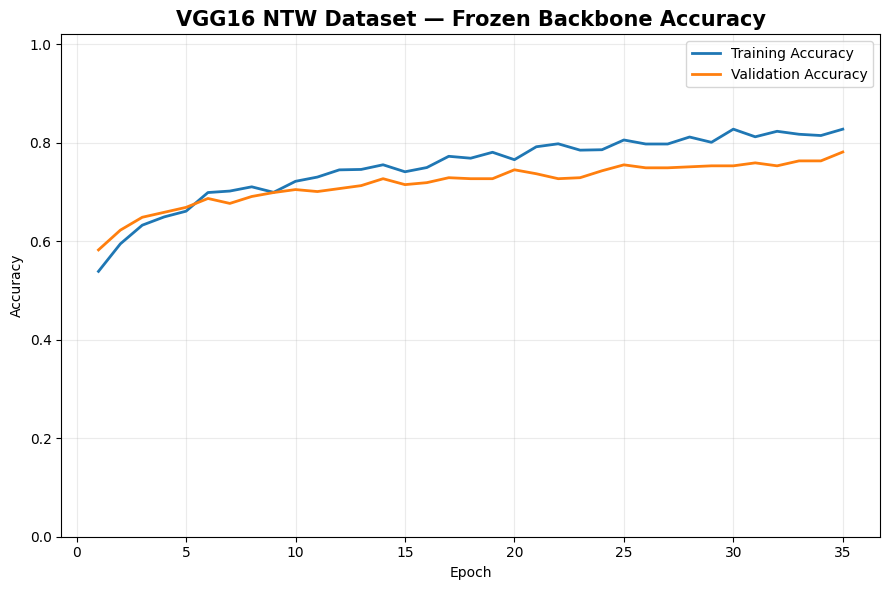

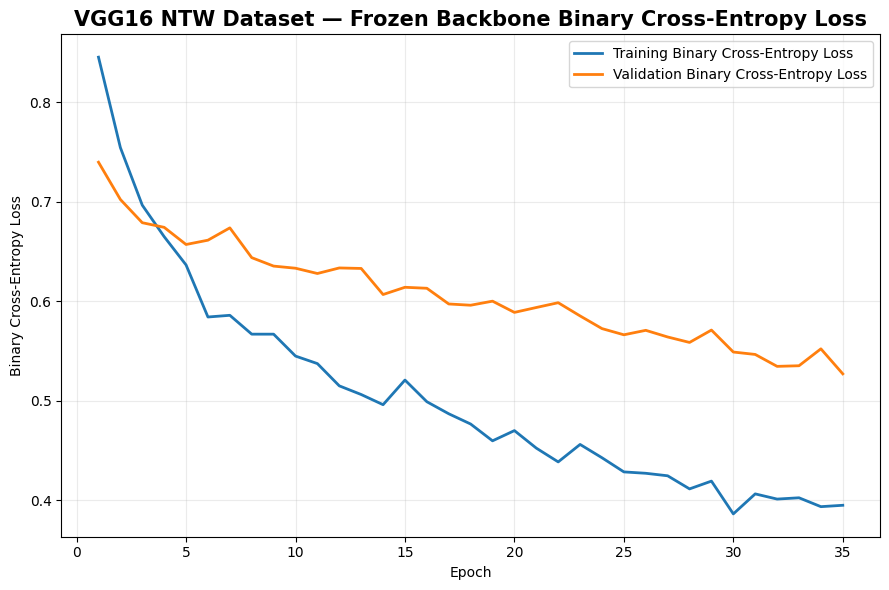

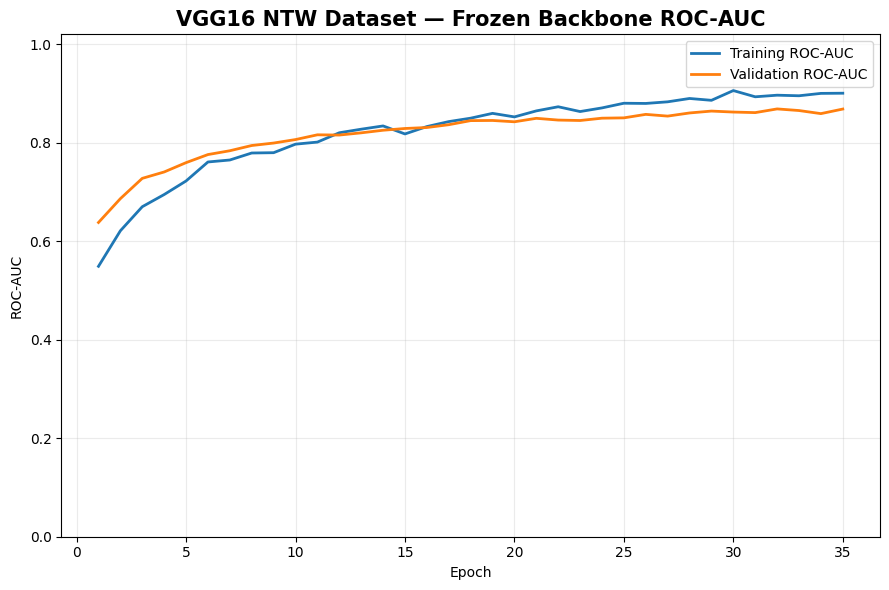

In [ ]:
FROZEN_DIR = Path(SAVE_DIR) / "VGG16_NTW_Frozen"
FROZEN_DIR.mkdir(parents=True, exist_ok=True)

frozen_model, frozen_backbone = build_vgg16_model("VGG16_NTW_Frozen")
frozen_backbone.trainable = False
compile_model(frozen_model, 1e-4)

save_summary(frozen_model, FROZEN_DIR / "model_summary.txt")
frozen_params = get_parameter_counts(frozen_model)
display(frozen_params)
frozen_params.to_csv(FROZEN_DIR / "parameter_counts.csv", index=False)

frozen_checkpoint = str(FROZEN_DIR / "best_model.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        frozen_checkpoint, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=4,
        min_lr=1e-7, verbose=1
    ),
    keras.callbacks.CSVLogger(str(FROZEN_DIR / "training_log.csv")),
]

frozen_hist_obj = frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FROZEN_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

frozen_history = combine_histories(frozen_hist_obj)
save_history(frozen_history, FROZEN_DIR, "VGG16_NTW_Frozen")
plot_history(
    frozen_history,
    FROZEN_DIR,
    "VGG16 NTW Dataset — Frozen Backbone",
    "VGG16_NTW_Frozen",
)

frozen_model = keras.models.load_model(frozen_checkpoint)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Test_Images
0,VGG16 NTW Dataset — Frozen Backbone,0.76506,0.722372,0.950355,0.523148,0.820827,0.873884,113,103,14,268,498


                 precision    recall  f1-score   support

Healthy Control     0.8898    0.5231    0.6589       216
      Parkinson     0.7224    0.9504    0.8208       282

       accuracy                         0.7651       498
      macro avg     0.8061    0.7368    0.7399       498
   weighted avg     0.7950    0.7651    0.7506       498



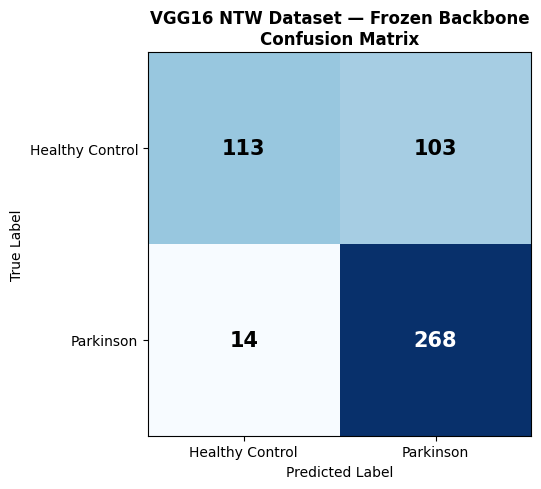

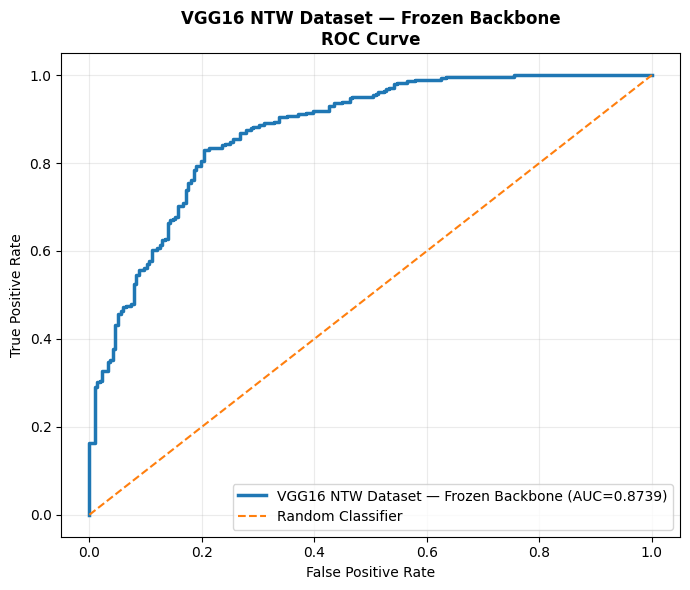

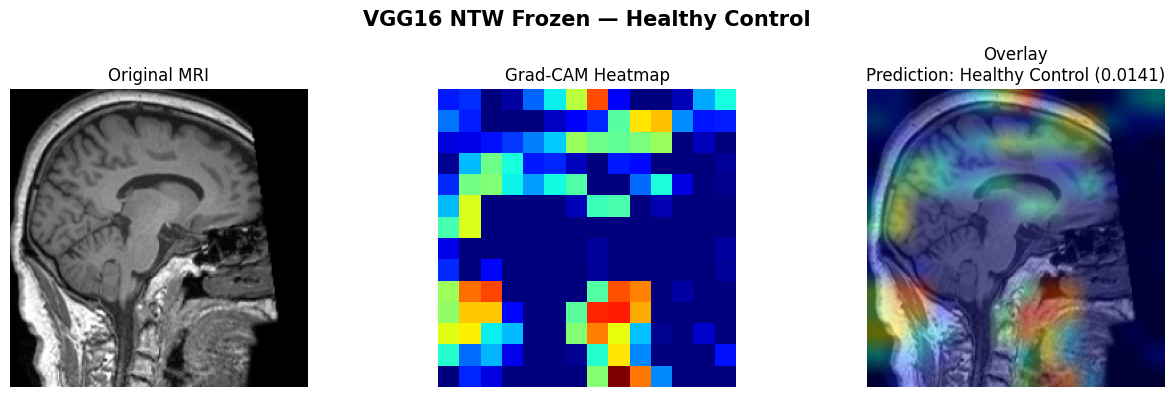

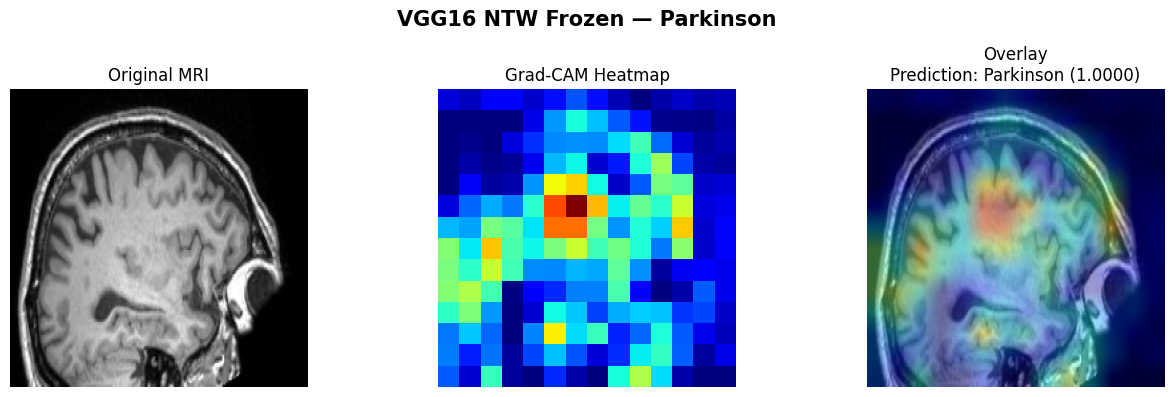

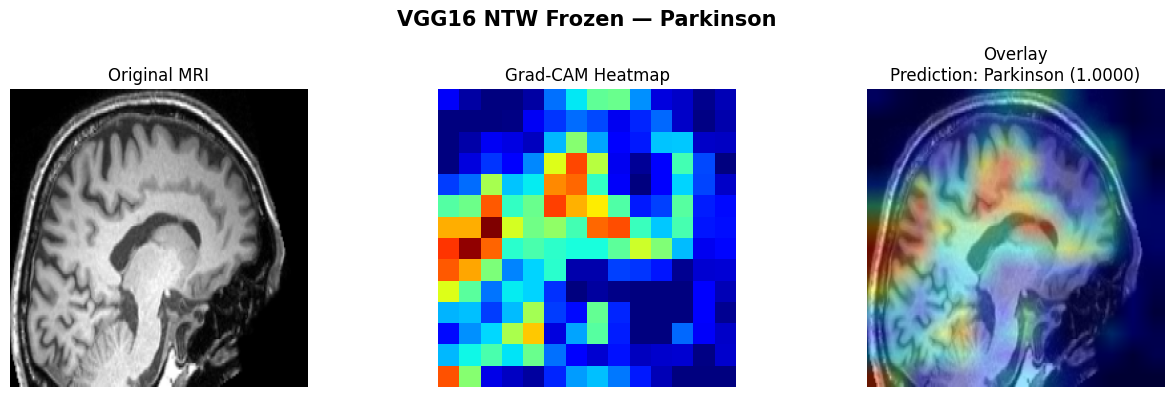

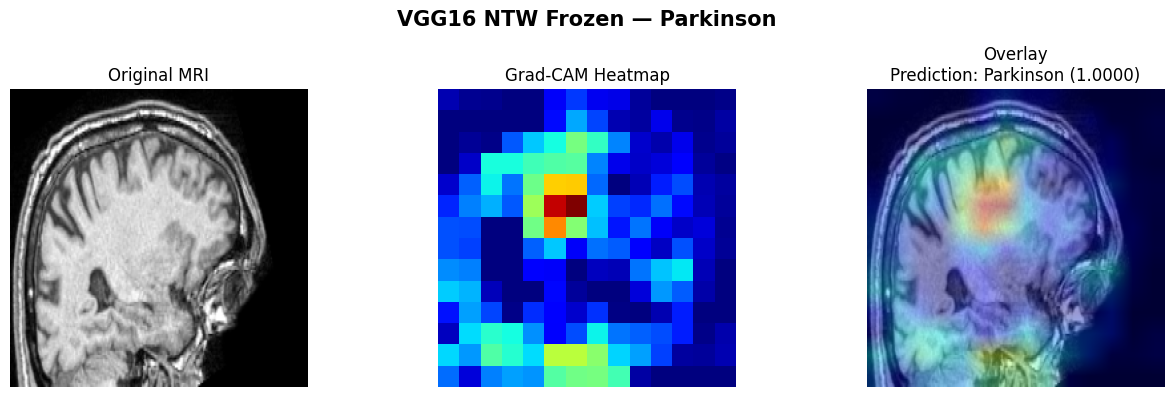

In [ ]:
frozen_metrics, frozen_predictions = evaluate_model(
    frozen_model, test_ds, test_df, FROZEN_DIR,
    "VGG16 NTW Dataset — Frozen Backbone",
    "VGG16_NTW_Frozen",
)

generate_gradcams(
    frozen_model,
    frozen_predictions,
    FROZEN_DIR,
    "VGG16_NTW_Frozen",
)

## Experiment 2 — Fine-Tuned VGG16 Backbone

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5278 - auc: 0.5456 - loss: 0.8366
Epoch 1: val_auc improved from None to 0.67225, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_FineTuned/warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_FineTuned/warmup_best.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.5491 - auc: 0.5613 - loss: 0.8147 - val_accuracy: 0.6185 - val_auc: 0.6722 - val_loss: 0.7343 - learning_rate: 1.0000e-04
Epoch 2/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6279 - auc: 0.6559 - loss: 0.7137
Epoch 2: val_auc improved from 0.67225 to 0.70963, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_f

Model: "VGG16_NTW_FineTuned"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_NTW_FineTuned,14848321,13111809,1736512


Epoch 11/35
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7215 - auc: 0.7925 - loss: 0.5560
Epoch 11: val_auc improved from None to 0.83641, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_FineTuned/best_model.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here/VGG16_NTW_FineTuned/best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.7375 - auc: 0.8106 - loss: 0.5299 - val_accuracy: 0.7149 - val_auc: 0.8364 - val_loss: 0.7107 - learning_rate: 5.0000e-06
Epoch 12/35
144/146 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7735 - auc: 0.8534 - loss: 0.4690
Epoch 12: val_auc improved from 0.83641 to 0.87813, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_model

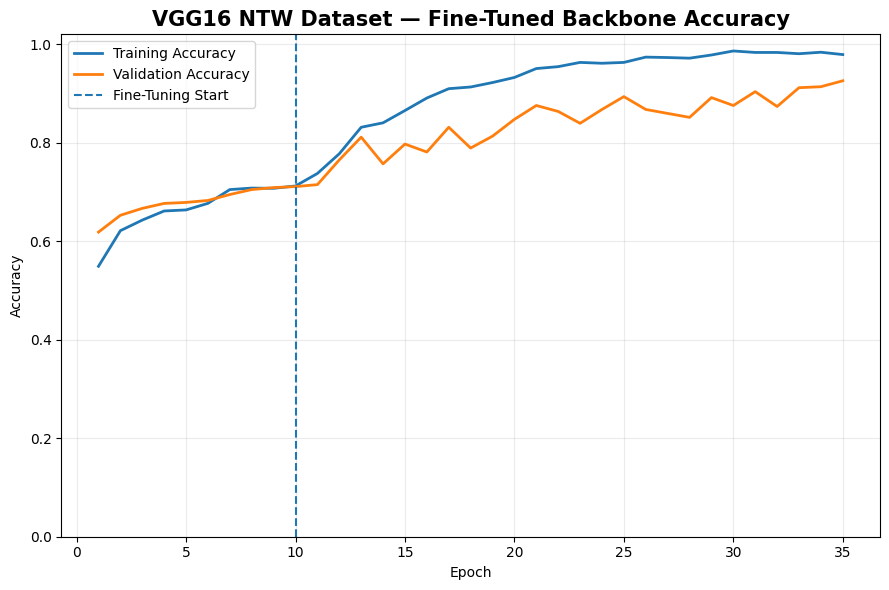

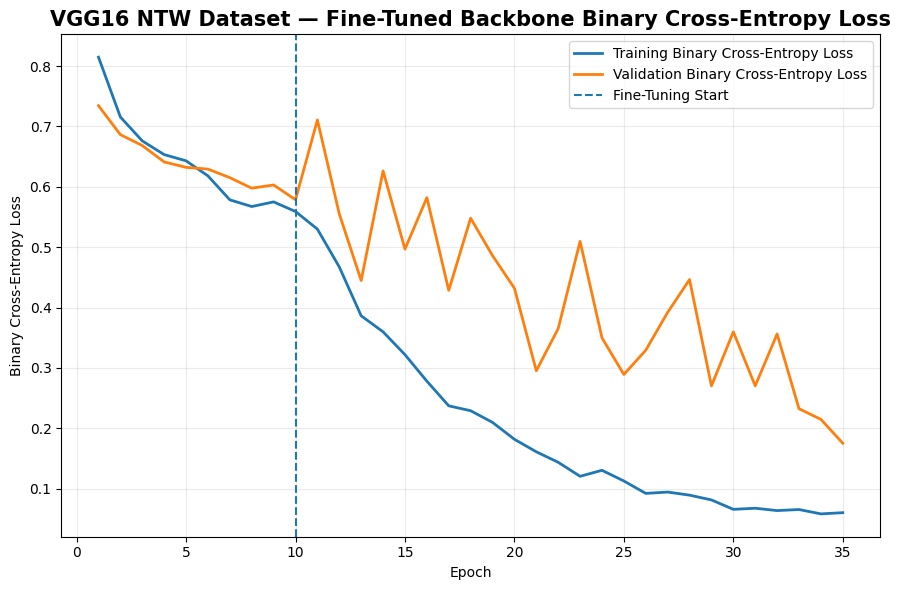

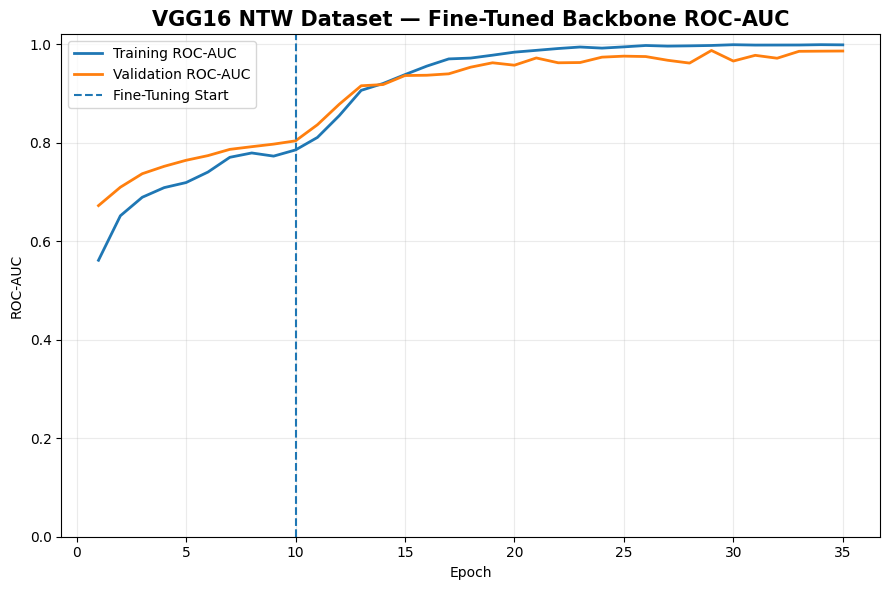

In [ ]:
FINETUNED_DIR = Path(SAVE_DIR) / "VGG16_NTW_FineTuned"
FINETUNED_DIR.mkdir(parents=True, exist_ok=True)

ft_model, ft_backbone = build_vgg16_model("VGG16_NTW_FineTuned")

# Stage 1: frozen warm-up
ft_backbone.trainable = False
compile_model(ft_model, 1e-4)

warmup_checkpoint = str(FINETUNED_DIR / "warmup_best.keras")
warmup_callbacks = [
    keras.callbacks.ModelCheckpoint(
        warmup_checkpoint, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=3,
        min_lr=1e-7, verbose=1
    ),
]

warmup_hist = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

ft_model = keras.models.load_model(warmup_checkpoint)
ft_backbone = get_backbone(ft_model)

# Stage 2: fine-tuning
ft_backbone.trainable = True
for layer in ft_backbone.layers[:-FINE_TUNE_LAST_LAYERS]:
    layer.trainable = False
for layer in ft_backbone.layers[-FINE_TUNE_LAST_LAYERS:]:
    layer.trainable = True

compile_model(ft_model, 5e-6)

save_summary(ft_model, FINETUNED_DIR / "model_summary.txt")
ft_params = get_parameter_counts(ft_model)
display(ft_params)
ft_params.to_csv(FINETUNED_DIR / "parameter_counts.csv", index=False)

ft_checkpoint = str(FINETUNED_DIR / "best_model.keras")
ft_callbacks = [
    keras.callbacks.ModelCheckpoint(
        ft_checkpoint, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=4,
        min_lr=1e-7, verbose=1
    ),
    keras.callbacks.CSVLogger(str(FINETUNED_DIR / "training_log.csv")),
]

finetune_hist = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
    callbacks=ft_callbacks,
    verbose=1,
)

ft_history = combine_histories(warmup_hist, finetune_hist)
save_history(ft_history, FINETUNED_DIR, "VGG16_NTW_FineTuned")
plot_history(
    ft_history,
    FINETUNED_DIR,
    "VGG16 NTW Dataset — Fine-Tuned Backbone",
    "VGG16_NTW_FineTuned",
    fine_tune_start=WARMUP_EPOCHS,
)

ft_model = keras.models.load_model(ft_checkpoint)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Test_Images
0,VGG16 NTW Dataset — Fine-Tuned Backbone,0.879518,0.824561,1.0,0.722222,0.903846,0.992694,156,60,0,282,498


                 precision    recall  f1-score   support

Healthy Control     1.0000    0.7222    0.8387       216
      Parkinson     0.8246    1.0000    0.9038       282

       accuracy                         0.8795       498
      macro avg     0.9123    0.8611    0.8713       498
   weighted avg     0.9007    0.8795    0.8756       498



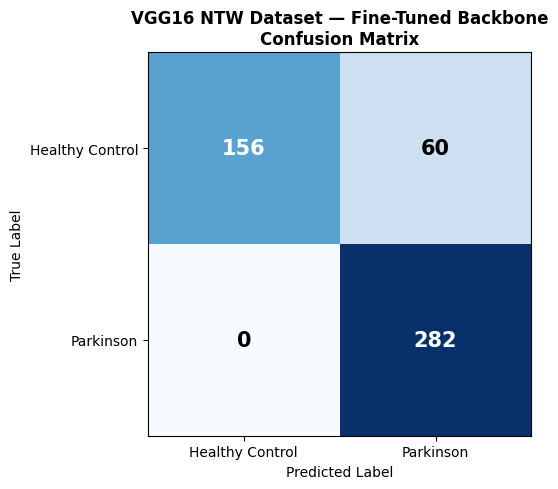

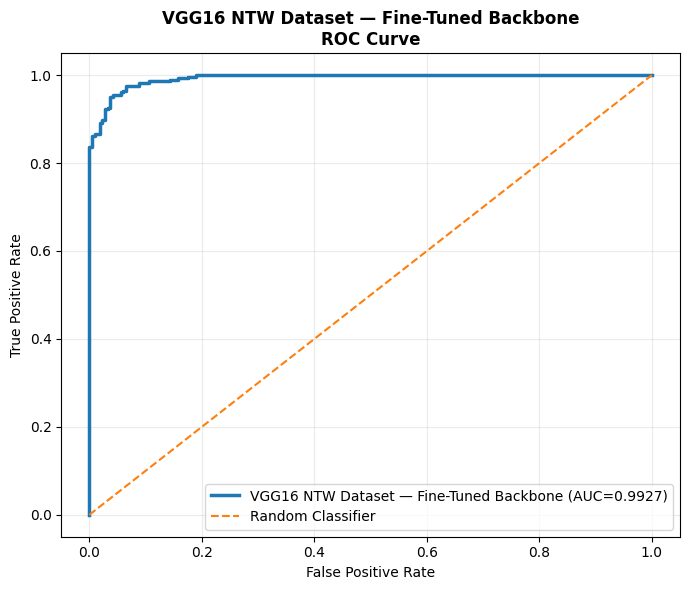

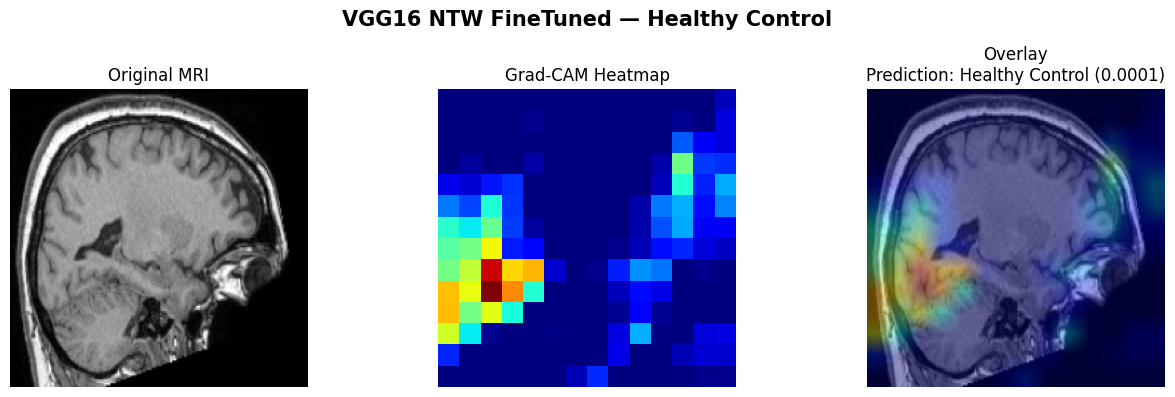

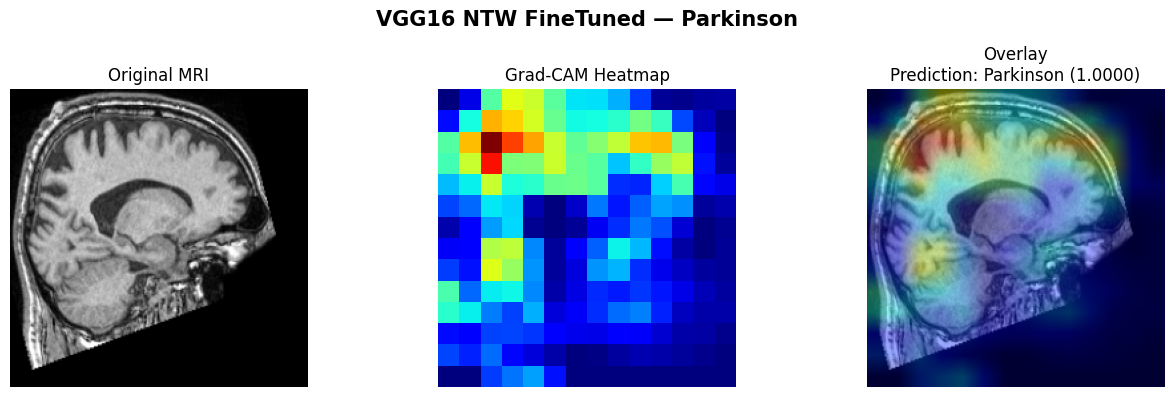

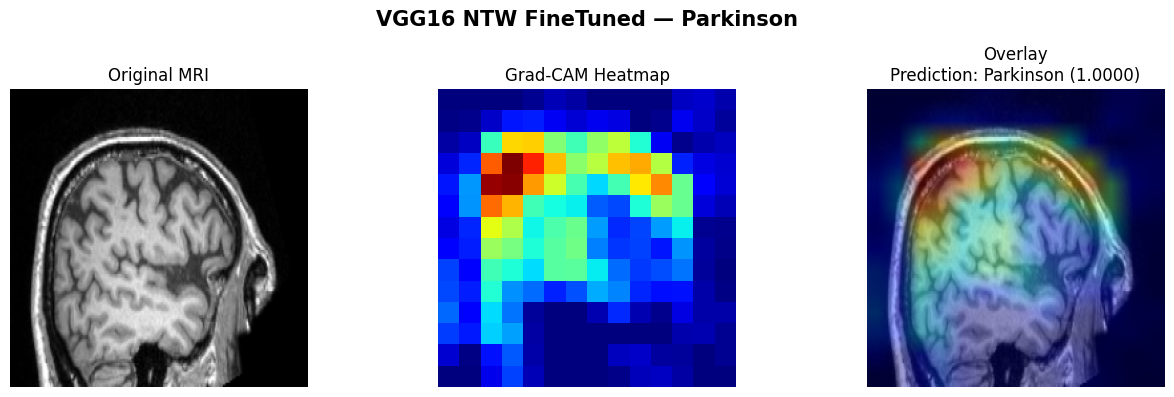

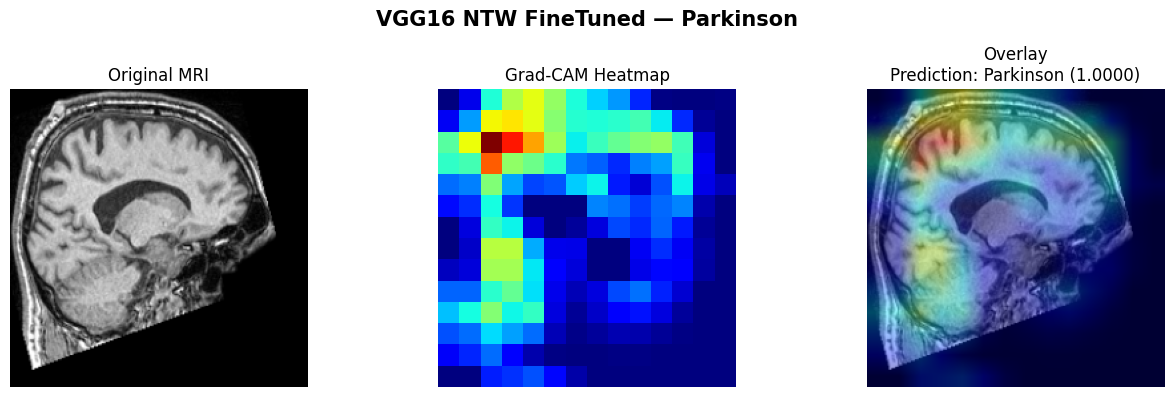

In [ ]:
ft_metrics, ft_predictions = evaluate_model(
    ft_model, test_ds, test_df, FINETUNED_DIR,
    "VGG16 NTW Dataset — Fine-Tuned Backbone",
    "VGG16_NTW_FineTuned",
)

generate_gradcams(
    ft_model,
    ft_predictions,
    FINETUNED_DIR,
    "VGG16_NTW_FineTuned",
)

In [ ]:
# =========================
# FINAL COMPARISON
# =========================
comparison = pd.DataFrame([frozen_metrics, ft_metrics])
display(comparison[[
    "Model", "Accuracy", "Precision", "Recall",
    "Specificity", "F1_Score", "ROC_AUC", "Test_Images"
]])

comparison.to_csv(
    Path(SAVE_DIR) / "VGG16_NTW_Frozen_vs_FineTuned.csv",
    index=False,
)

print("Finished. Results saved in:", SAVE_DIR)

,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,Test_Images
0,VGG16 NTW Dataset — Frozen Backbone,0.765060,0.722372,0.950355,0.523148,0.820827,0.873884,498
1,VGG16 NTW Dataset — Fine-Tuned Backbone,0.879518,0.824561,1.000000,0.722222,0.903846,0.992694,498


Finished. Results saved in: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_image_level_ntw_files/VGG16_NTW_image_level_data_save_here
